# **NLP701@MBZUAI Fall 2025 - Lab 04**
- Topic: **Syntactic Parsing and Context-Free Grammar**

## **Today's Agenda**
- Observe syntactic ambiguities in language
- Compare trees across different languages

**Prerequisites**: Run the following command to install required libraries for today's exercise.

In [1]:
!pip install svgling transformers stanza conllu

  Using cached svgwrite-1.4.3-py3-none-any.whl.metadata (8.8 kB)
Using cached svgwrite-1.4.3-py3-none-any.whl (67 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [svgling]


# **Constituency Tree and its Ambiguity**

## **Ambiguity**
We saw some examples of syntactic ambiguities in the lecture.
Let's examine the following examples.
- the woman saw a man with a telescope
- plastic water bottle
- old men and women

In [2]:
import nltk
from nltk.tree import Tree
from IPython.display import display

### **PP Attachment**
**"the woman saw a man with a telescope"**

We first define a CFG using NLTK's `nltk.CFG.fromstring()`:

In [3]:
grammar = nltk.grammar.CFG.fromstring("""
S -> NP VP
PP -> P NP
NP -> Det N | Det N PP
VP -> V NP | VP PP
Det -> 'a' | 'the'
N -> 'man' | 'woman' | 'telescope'
V -> 'saw'
P -> 'with'
""")

In [4]:
sent = 'the woman saw a man with a telescope'.split()

Parse the sentence:

In [5]:
parser = nltk.ChartParser(grammar)

for tree in parser.parse(sent):
    print(tree)

(S
  (NP (Det the) (N woman))
  (VP
    (VP (V saw) (NP (Det a) (N man)))
    (PP (P with) (NP (Det a) (N telescope)))))
(S
  (NP (Det the) (N woman))
  (VP
    (V saw)
    (NP (Det a) (N man) (PP (P with) (NP (Det a) (N telescope))))))


If you have Ghostscript, you could use `display()` to visualize the tree. Without Ghostscript, use the `draw()` method.

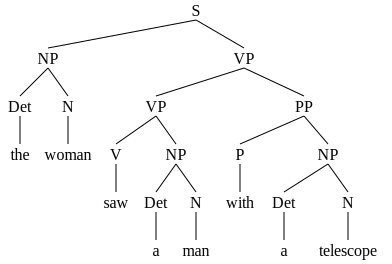

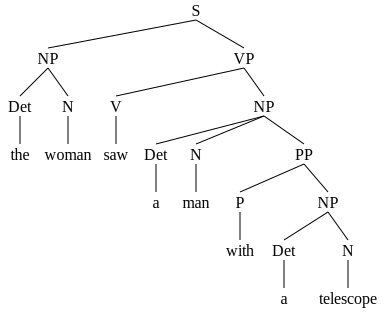

In [6]:
for tree in parser.parse(sent):
    # tree.draw()
    display(tree)

### **Exercise 01: Compound Nouns**
**"plastic water bottle"**

Now, design a grammar to parse the following sentence. Your grammar should produce two different trees:

In [7]:
text = "plastic water bottle".split()

In [8]:
# plastic water bottle
grammar = nltk.CFG.fromstring("""
S -> NP
NP -> Adj NP | N NP | N
Adj -> 'plastic'
N -> 'water' | 'bottle'
""")

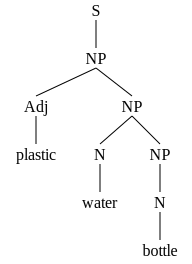

In [9]:
parser = nltk.ChartParser(grammar)
for tree in parser.parse(text):
    # tree.draw()
    display(tree)

### **Exercise 02: Coordination**
**"old men and women"**

Now, design a grammar to parse the following sentence. Your grammar should produce two different trees:

In [10]:
text = "old men and women".split()

In [11]:
grammar = nltk.CFG.fromstring("""
S -> NP
NP -> NP Conj NP      | Adj NP      | N
Adj -> 'old'
N   -> 'men' | 'women'
Conj -> 'and'
""")

In [12]:
!pip install svgling

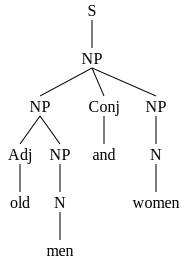

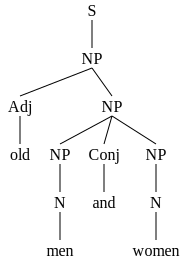

In [13]:
parser = nltk.ChartParser(grammar)
for tree in parser.parse(text):
    # tree.draw()
    display(tree)

# **Date Palm and Bonsai**
<img src="https://cdn.britannica.com/24/162724-050-6C219853/Date-palm.jpg" width="500"/>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/66/Bonsai_tree2.jpg/2560px-Bonsai_tree2.jpg" width="500"/>

**Is there any difference in tree structure across different languages?**

To explore this, we are going to use **Parallel Universal Dependencies (PUD)**.
This dataset allows us to compare syntactic structure across different languages in a controlled way.
Parallel Universal Dependencies (PUD) is a collection of dependency treebanks that are parallel to each other.
There are 1,000 sentences in each language, always in the same order.
It was created for the [CoNLL 2017 shared task on Multilingual Parsing from Raw Text to Universal Dependencies](http://universaldependencies.org/conll17/).

Let's look at how trees are different in Arabic and Japanese!

## **Download and Preprocesss PUD**

In [14]:
%%bash
git clone https://github.com/UniversalDependencies/UD_Italian-PUD
git clone https://github.com/UniversalDependencies/UD_Japanese-PUD
git clone https://github.com/UniversalDependencies/UD_English-PUD

Cloning into 'UD_Italian-PUD'...


Cloning into 'UD_Japanese-PUD'...
Cloning into 'UD_English-PUD'...


First, we define a function to read the `conllu` format.

In [15]:
!pip install conllu

In [16]:
from conllu import parse_incr

# define a function that reads the conllu format file
def read_conll(fpath) -> list:
    instances = []
    with open(fpath, mode='r') as f:
        for sentence in parse_incr(f):
            instances.append(
                [token['form']
                  for token in sentence if type(token['id']) is int] # we need this to exclude MWEs

            )
    return instances

Load the data.

In [17]:
english_sents = read_conll('./UD_English-PUD/en_pud-ud-test.conllu')
japanese_sents = read_conll('./UD_Japanese-PUD/ja_pud-ud-test.conllu')
italian_sents = read_conll('./UD_Italian-PUD/it_pud-ud-test.conllu')

Check the output.

In [18]:
english_sents[0]

['“',
 'While',
 'much',
 'of',
 'the',
 'digital',
 'transition',
 'is',
 'unprecedented',
 'in',
 'the',
 'United',
 'States',
 ',',
 'the',
 'peaceful',
 'transition',
 'of',
 'power',
 'is',
 'not',
 ',',
 '”',
 'Obama',
 'special',
 'assistant',
 'Kori',
 'Schulman',
 'wrote',
 'in',
 'a',
 'blog',
 'post',
 'Monday',
 '.']

## **Parsing with  Stanza**

Now that our input data is ready, we can parse sentences using a constituency parser.
We will use the  [Stanza parser](https://stanfordnlp.github.io/stanza/constituency.html).

In [19]:
!pip install stanza

In [20]:
# stanza parser
import stanza

/home/khang.nhat/anaconda3/envs/nlplab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
english_parser = stanza.Pipeline(
    lang='en',
    processors='tokenize,mwt,pos,constituency',
    tokenize_pretokenized=True)

italian_parser = stanza.Pipeline(
    lang='it',
    processors='tokenize,mwt,pos,constituency',
    tokenize_pretokenized=True)

japanese_parser = stanza.Pipeline(
    lang='ja',
    processors='tokenize,pos,constituency',
    tokenize_pretokenized=True)

2026-03-28 06:53:13 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-03-28 06:53:13 INFO: Downloaded file to /home/khang.nhat/.cache/stanza/1.11.0/resources/resources.json
2026-03-28 06:53:17 INFO: Loading these models for language: en (English):
| Processor    | Package             |
--------------------------------------
| tokenize     | combined            |
| mwt          | combined            |
| pos          | combined_charlm     |
| constituency | ptb3-revised_charlm |

/home/khang.nhat/anaconda3/envs/nlplab/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org

Stanza parser requires postprocessing if we want to visualize the output using NLTK's `Tree` module.

In [22]:
# japanese
# we need post-processing that transforms the bracket represntation to NLTK's tree format
from nltk.tree import Tree

# parse and convert the output to NLTK's tree format
english_trees = [Tree.fromstring(str(sent.constituency))
                    for sent in english_parser(english_sents).sentences]
italian_trees = [Tree.fromstring(str(sent.constituency))
                    for sent in italian_parser(italian_sents).sentences]
japanese_trees = [Tree.fromstring(str(sent.constituency))
                    for sent in japanese_parser(japanese_sents).sentences]

## **Compare Trees across Different Languages**

# Parallel Sentence: 1
Who are they ?


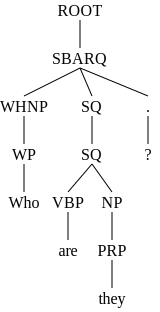

Chi sono ?


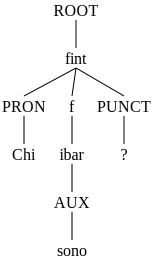

彼 ら は 誰 です か 。


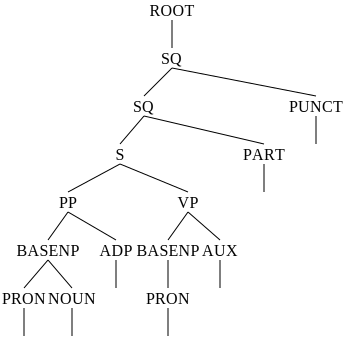

# Parallel Sentence: 2
Drop the mic .


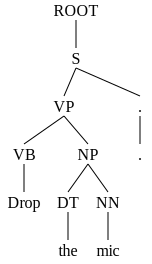

Fa' cadere il microfono .


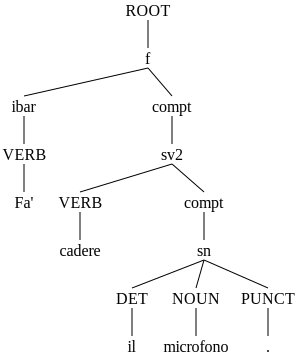

マイク を 落とす 。


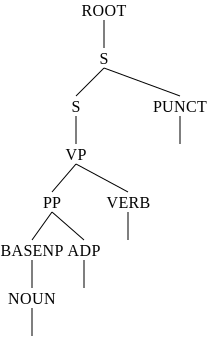

In [23]:
max_length = 5 # max sentence length
short_sents = [i for i in range(len(english_sents)) if len(english_sents[i]) < max_length] # filter out long sentences

for i, j in enumerate(short_sents):
    print(f'# Parallel Sentence: {i+1}')

    print(' '.join(english_sents[j]))
    #english_trees[j].draw()
    display(english_trees[j])
    print(' '.join(italian_sents[j]))
    #italian_trees[j].draw()
    display(italian_trees[j])
    print(' '.join(japanese_sents[j]))
    #japanese_trees[j].draw()
    display(japanese_trees[j])

## **Exercise 03: Try different languages**
Compare syntactic structure across different langauges.
First, you will need to download data from [UD's GitHub repository](https://github.com/UniversalDependencies).
Here's a list of languages that are available in Stanza.

```python

# a map for available languages in Stanza parser
model_stanza = {
    'english': 'en',
    'chinese': 'zh',
    'danish': 'da',
    'italian': 'it',
    'japanese': 'ja',
    'portuguese': 'pt',
    'spanish': 'es',
    'turkish': 'tr',
}
```

In [24]:
%%bash
git clone https://github.com/UniversalDependencies/UD_Chinese-PUD.git

Cloning into 'UD_Chinese-PUD'...


In [25]:
chinese_parser = stanza.Pipeline(
    lang='zh',
    processors='tokenize,pos,constituency',
    tokenize_pretokenized=True)

2026-03-28 06:54:41 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-03-28 06:54:41 INFO: Downloaded file to /home/khang.nhat/.cache/stanza/1.11.0/resources/resources.json
2026-03-28 06:54:41 INFO: "zh" is an alias for "zh-hans"
2026-03-28 06:54:58 INFO: Loading these models for language: zh-hans (Simplified_Chinese):
| Processor    | Package        |
---------------------------------
| tokenize     | gsdsimp        |
| pos          | gsdsimp_charlm |
| constituency | ctb-51_charlm  |

2026-03-28 06:54:58 INFO: Using device: cpu
2026-03-28 06:54:58 INFO: Loading: tokenize
2026-03-28 06:54:58 INFO: Loading: pos
2026-03-28 06:54:59 INFO: Loading: constituency
2026-03-28 06:55:00 INFO: Done loading processors!


In [26]:
chinese_sents = read_conll('./UD_Chinese-PUD/zh_pud-ud-test.conllu')

In [27]:
# japanese
# we need post-processing that transforms the bracket represntation to NLTK's tree format
from nltk.tree import Tree

# parse and convert the output to NLTK's tree format
chinese_trees = [Tree.fromstring(str(sent.constituency))
                    for sent in chinese_parser(chinese_sents).sentences]

# Parallel Sentence: 1
他 主張 嚴刑 。


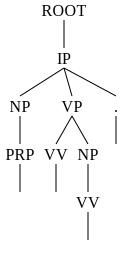

# Parallel Sentence: 2
裙子 很 現代化 。


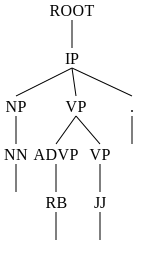

# Parallel Sentence: 3
放下 麥克風 。


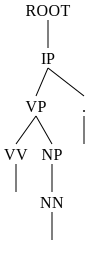

# Parallel Sentence: 4
這 需要 評估 。


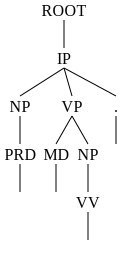

In [28]:
max_length = 5 # max sentence length
short_sents = [i for i in range(len(chinese_sents)) if len(chinese_sents[i]) < max_length] # filter out long sentences

for i, j in enumerate(short_sents):
    print(f'# Parallel Sentence: {i+1}')
    print(' '.join(chinese_sents[j]))
    #english_trees[j].draw()
    display(chinese_trees[j])

# **Acknowledgement**

- https://www.nltk.org/book/ch08.html